In [1]:
import numpy as np
from estimation import _calculate_statistics, _analyze_threshold_trends
import matplotlib.pyplot as plt
import os



from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
# from monster import main_alt

logger = setup_logger()



In [2]:
%load_ext autoreload
%autoreload 2

In [3]:

trend_data_nothing = main_alt(dark_mean_correction=False, diffmap_mean_correction=False)
trend_data_only_dark = main_alt(dark_mean_correction=True, diffmap_mean_correction=False)
trend_data_both = main_alt(dark_mean_correction=True, diffmap_mean_correction=True)
trend_data_both_v2 = main_alt(dark_mean_correction=True,diffmap_mean_correction=True, diffmap_v2_correction=True)


NameError: name 'main_alt' is not defined

NameError: name 'trend_data_nothing' is not defined

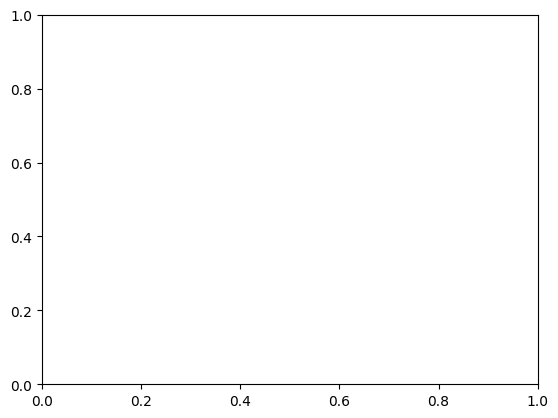

In [4]:
fig, ax = plt.subplots()
ax.plot(trend_data_nothing["mean"], trend_data_nothing["threshold"], label="No correction", )
ax.plot(trend_data_only_dark["mean"], trend_data_only_dark["threshold"], label="Only dark correction", )
ax.plot(trend_data_both["mean"], trend_data_both["threshold"], label="Both corrections", )
ax.plot(trend_data_both_v2["mean"], trend_data_both_v2["threshold"], label="Both corrections V2", )
ax.set_xlabel("Mean of Difference Map voxel values")
ax.set_ylabel("Intensity Threshold")
ax.legend()
plt.show()


2026-02-18 16:02:41,054: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:02:42,956: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:02:42,958: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:02:43 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:02:43 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:02:43 [info     ] Computing difference map.     
2026-02-18 16:02:43 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:02:43 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:02:46 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:02:46,171: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:02:46,172: logger: INFO: Diffmap zero frequency: 1.7881393432617188e-07 (processing.py:302)
2026-02-18 16:02:46,194: logger: WARNING: Diffmap Mean: 0.000000, Std: 0.001062 (3778884215.py:10)
2026-02-18 16:02:46,232: logger: WARNING: Used threshold for posmask: 0.071, found 833 blobs (masking.py:133)
2026-02-18 16:02:46,237: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-02-18 16:02:46,237: logger: INFO: Maximum Blob sizes found: 893 (masking.py:151)
2026-02-18 16:02:46,367: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-02-18 16:02:46,445: logger: INFO: Excluding 649 (4.46%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blo

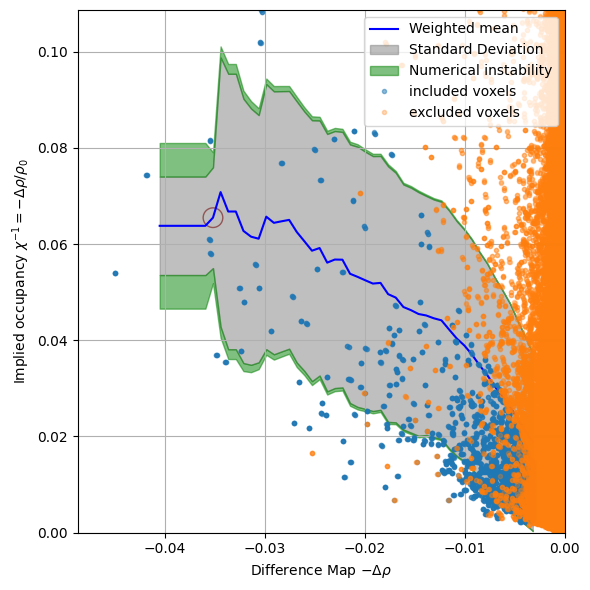

In [15]:
from monster import apply_config
config = apply_config()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = False
config["map_processing"]["diffmap_v2_correction"] = False
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
plt.show()
fig.savefig("temp.png")


2026-02-18 16:39:25,751: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:39:27,827: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:39:27,829: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:39:28 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:39:28 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:39:28 [info     ] Computing difference map.     
2026-02-18 16:39:28 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:39:28 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:39:31 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:39:31,283: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:39:31,307: logger: INFO: Diffmap std: 0.001 (processing.py:274)
2026-02-18 16:39:31,308: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:275)
2026-02-18 16:39:31,372: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-18 16:39:31,381: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-18 16:39:31,407: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-18 16:39:31,468: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:217)
2026-02-18 16:39:31,478: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:231)
2026-02-18 16:39:31,504: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-18 16:39:31,504: logger: INFO: this is calcul

2026-02-18 16:39:31 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:39:32 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:39:32 [info     ] Computing difference map.     
2026-02-18 16:39:32 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:39:32 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:39:35 [info     ] Map TV-denoised with fixed weight final_negentropy=1.55e-01 initial_negentropy=5.26e-03 weight=0.005807665501203384


2026-02-18 16:39:35,028: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:39:35,029: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:302)
2026-02-18 16:39:35,030: logger: WARNING: Diffmap zero frequency: -4122.96875 (processing.py:321)
2026-02-18 16:39:35,052: logger: WARNING: Diffmap Mean: -0.002926, Std: 0.002975 (3097433349.py:10)
2026-02-18 16:39:35,093: logger: WARNING: Used threshold for posmask: 0.134, found 1921 blobs (masking.py:133)
2026-02-18 16:39:35,098: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-02-18 16:39:35,098: logger: INFO: Maximum Blob sizes found: 411 (masking.py:151)
2026-02-18 16:39:35,335: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-02-18 16:39:35,410: logger: INFO: Excluding 558 (3.87%) vo

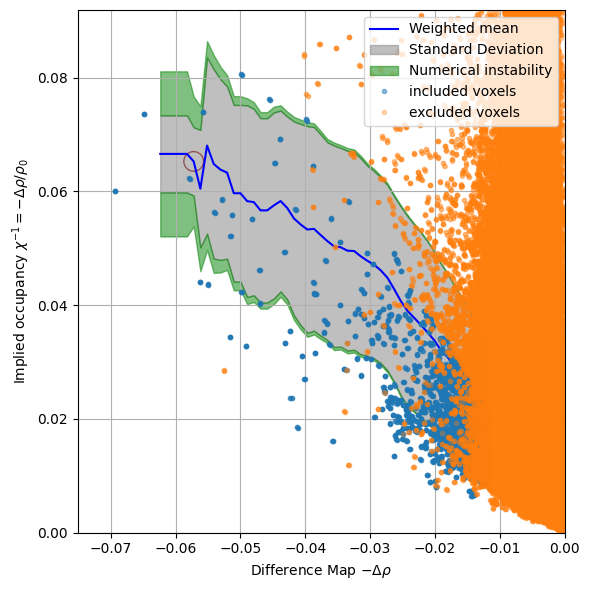

In [25]:
from monster import apply_config
config = apply_config()
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
plt.show()



In [ ]:
from monster import apply_config
config = apply_config()
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = True
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )


2026-02-18 16:41:30,299: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:41:32,196: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:41:32,197: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:41:32 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:41:33 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:41:33 [info     ] Computing difference map.     
2026-02-18 16:41:33 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:41:33 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:41:35 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:41:35,503: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:41:35,527: logger: INFO: Diffmap std: 0.001 (processing.py:274)
2026-02-18 16:41:35,528: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:275)
2026-02-18 16:41:35,591: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-18 16:41:35,600: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-18 16:41:35,624: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-18 16:41:35,686: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:217)
2026-02-18 16:41:35,696: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:231)
2026-02-18 16:41:35,721: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-18 16:41:35,722: logger: INFO: Diffmap zero f

In [47]:

config['masking']['dark_size_threshold'] = -1
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)

# fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
# ax.axvline(-np.percentile(np.abs(diffmap_np),50))
# ax.axvline(-np.percentile(np.abs(diffmap_np),80))
ax.axvline(-np.percentile(np.abs(diffmap_np),95))
# ax.axvline(-2*np.std(np.abs(diffmap_np)))
# ax.plot([0,-1], [0, np.max(np.abs(diffmap_np)*np.max(map_dark_np))*10], label="Std of Abs Diffmap", color="green", linestyle="--")

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Mean of diffmap_np: {np.mean(diffmap_np)}, Mean of map_dark_np: {np.mean(map_dark_np)}"
)
stats_data = _calculate_statistics(diffmap_np, map_dark_np, inclusion_mask)
# trend_data = _analyze_threshold_trends(
#     stats_data["diffmap_masked"],
#     stats_data["pseudo_occupancy"],
#     stats_data["weight"],
# )
diffline = np.linspace(-1,0, 100)
cutoff_dark = map_dark_np.mean()+ config['masking']['dark_size_threshold'] * map_dark_np.std()
ax.plot( diffline,-diffline / cutoff_dark, 'r--', label='Dark Size Threshold')
cutoff_dark = map_dark_np.mean()+  map_dark_np.std()* 0.1
ax.plot( diffline,-diffline / cutoff_dark, 'g--', label='Dark Size Threshold')
ax.set_ylim(0, 0.2)
plt.show()


2026-02-18 16:59:36,084: logger: WARNING: Used threshold for posmask: 0.071, found 833 blobs (masking.py:133)
2026-02-18 16:59:36,089: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-02-18 16:59:36,090: logger: INFO: Maximum Blob sizes found: 893 (masking.py:151)
2026-02-18 16:59:36,251: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-02-18 16:59:36,322: logger: INFO: Excluding 3470 (23.85%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-02-18 16:59:36,351: logger: INFO: Excluding an addtional 1658 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-02-18 16:59:36,376: logger: WARNING: Excluding an 

In [48]:
def get_diffmaps(dark_mean_correction=False, diffmap_mean_correction=False, diffmap_v2_correction=False):
    config = apply_config()
    config["map_processing"]["diffmap_mean_correction"] = diffmap_mean_correction
    config["map_processing"]["dark_mean_correction"] = dark_mean_correction
    config["map_processing"]["diffmap_v2_correction"] = diffmap_v2_correction
    unscaled_dark, unscaled_triggered = get_maps(config)
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

    return diffmap


diffmap_none = get_diffmaps(
    dark_mean_correction=False, 
    diffmap_mean_correction=False, 
    diffmap_v2_correction=False)
diffmap_both = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=True, 
    diffmap_v2_correction=False)
diffmap_v2 = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=True, 
    diffmap_v2_correction=True)


2026-02-18 16:59:38,142: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:59:40,019: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:59:40,020: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:59:40 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:59:40 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:59:40 [info     ] Computing difference map.     
2026-02-18 16:59:40 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:59:40 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:59:43 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:59:43,318: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:59:43,319: logger: INFO: Diffmap zero frequency: 1.7881393432617188e-07 (processing.py:302)
2026-02-18 16:59:43,359: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


...

2026-02-18 16:59:51,991: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:59:51,992: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:302)
2026-02-18 16:59:51,993: logger: WARNING: Diffmap zero frequency: -4122.96875 (processing.py:321)
2026-02-18 16:59:52,032: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:59:53,859: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:59:53,860: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:59:54 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:59:54 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:59:54 [info     ] Computing difference map.     
2026-02-18 16:59:54 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:59:54 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:59:57 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:59:57,082: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:59:57,105: logger: INFO: Diffmap std: 0.001 (processing.py:274)
2026-02-18 16:59:57,106: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:275)
2026-02-18 16:59:57,165: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-18 16:59:57,174: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-18 16:59:57,199: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-18 16:59:57,258: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:217)
2026-02-18 16:59:57,268: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:231)
2026-02-18 16:59:57,291: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-18 16:59:57,292: logger: INFO: Diffmap zero f

In [49]:
diffmap_dark = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=False, 
    diffmap_v2_correction=False)


2026-02-18 16:59:57,347: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:59:59,188: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:59:59,189: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:59:59 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 17:00:00 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 17:00:00 [info     ] Computing difference map.     
2026-02-18 17:00:00 [info     ]   using fixed                  kparameter=0.07
2026-02-18 17:00:00 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 17:00:02 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 17:00:02,540: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 17:00:02,562: logger: INFO: Diffmap std: 0.001 (processing.py:274)
2026-02-18 17:00:02,563: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:275)
2026-02-18 17:00:02,626: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-18 17:00:02,634: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-18 17:00:02,658: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-18 17:00:02,719: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:217)
2026-02-18 17:00:02,729: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:231)
2026-02-18 17:00:02,753: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-18 17:00:02,753: logger: INFO: this is calcul

2026-02-18 17:00:03 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 17:00:03 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 17:00:03 [info     ] Computing difference map.     
2026-02-18 17:00:03 [info     ]   using fixed                  kparameter=0.07
2026-02-18 17:00:03 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 17:00:06 [info     ] Map TV-denoised with fixed weight final_negentropy=1.55e-01 initial_negentropy=5.26e-03 weight=0.005807665501203384


2026-02-18 17:00:06,145: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 17:00:06,146: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:302)


In [50]:
k = 25
# np.partition(np.abs(diffmap_none - diffmap_both)["F"], -k)[-k:]
np.partition(np.abs(diffmap_v2 - diffmap_both)["F"], -k)[-k:]
# diffmap_v2 - diffmap_both
# diffmap_v2 - diffmap_none
# np.partition(np.abs(diffmap_v2 - diffmap_none)["F"], -5)[-5:] 

array([34.642048, 34.962906, 35.05324 , 40.479927, 36.182526, 36.78347 ,
       38.39808 , 35.71168 , 36.32284 , 42.121384, 44.25109 , 35.892406,
       38.326313, 37.14542 , 36.884373, 37.496983, 39.595116, 36.085133,
       45.088154, 41.269215, 39.29129 , 38.231754, 37.64419 , 36.360794,
       42.181126], dtype=float32)

In [34]:

np.partition((diffmap_both)["F"], -k)[-k:], np.partition((diffmap_v2)["F"], -k)[-k:]

(array([46.260662, 46.314034, 46.346474, 46.459118, 46.56161 , 47.057083,
        47.792854, 48.862274, 49.40094 , 48.294502, 49.02378 , 47.64422 ,
        50.620403, 47.720734, 47.409863, 47.769306, 48.896614, 47.313137,
        49.71831 , 49.77447 , 49.88201 , 47.444435, 47.17728 , 49.74148 ,
        51.6721  ], dtype=float32),
 array([19.560114, 19.704008, 19.799198, 23.423077, 24.657536, 20.885685,
        20.136642, 22.606974, 21.08106 , 24.631668, 25.147888, 19.983503,
        22.194738, 20.360807, 25.374449, 21.623962, 28.080046, 21.369673,
        21.34885 , 22.547691, 22.941494, 22.452763, 20.71508 , 21.223156,
        21.363565], dtype=float32))

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

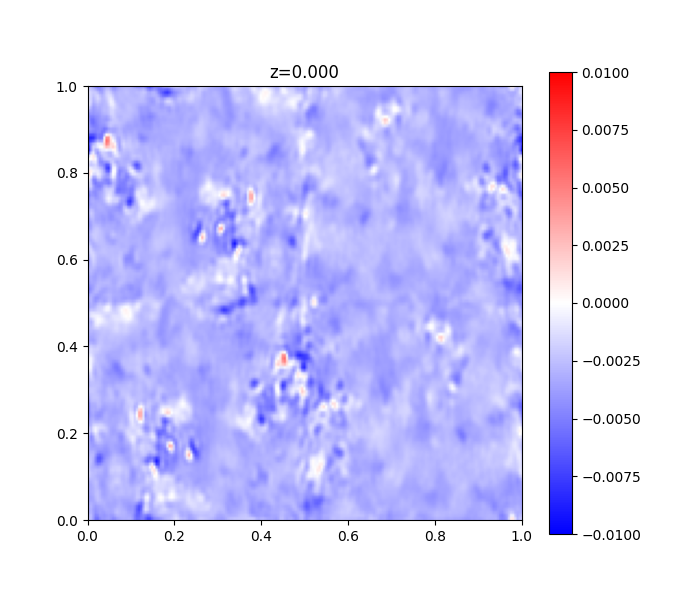

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

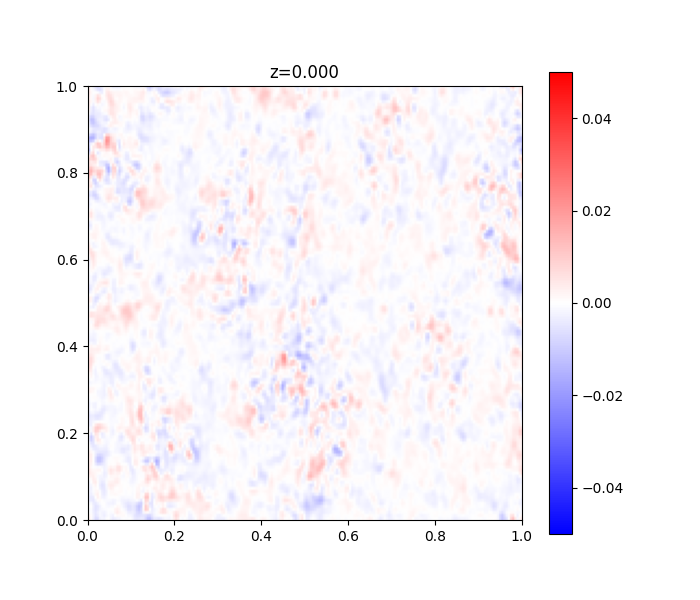

In [54]:
from plotting3d import slice_3d
%matplotlib widget
diffmap_v2_np = diffmap_v2.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
diffmap_dark_np = diffmap_dark.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
diffmap_both_np = diffmap_both.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
imkwargs= {"cmap":"bwr", "vmax":0.05, "vmin":-0.05}
imkwargs2= {"cmap":"bwr", "vmax":0.01, "vmin":-0.01}
_ = slice_3d(diffmap_v2_np, imkwargs=imkwargs2)
plt.show()
_ = slice_3d(diffmap_dark_np, imkwargs=imkwargs)
plt.show()
# _ = slice_3d(diffmap_both_np, imkwargs=imkwargs)

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

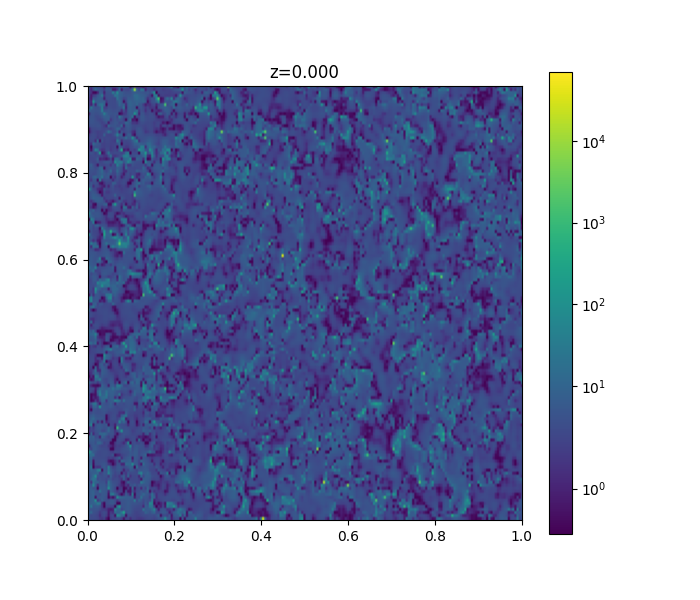

In [53]:
diffmap_none_np = diffmap_none.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])

_ = slice_3d(np.abs(diffmap_dark_np)/np.abs(diffmap_none_np), imkwargs = dict(norm="symlog"))
plt.show()


In [ ]:
=a1))
plt.show()
